# Análisis de Absentismo Laboral - RRHH (13-JUL-2026)

---

### Preguntas de negocio

> Cómo influyen  en los niveles de absentismo los factores de:
- el consumo social de alcohol
- el consumo social de tabaco 
- los antecedentes disciplinarios

 > Cómo podríamos diseñar acciones preventivas y culturales para promover un entorno laboral más saludable y minimizar el impacto del absentismo?
 ---


### Antecedente:

En la semana anterior se desarrolló un modelo de regresión logística binaria, en el que la variable dependiente clasificaba a los empleados según pertenecieran o no al grupo de alto absentismo.
Resultados: sólo `Disciplinary Failure` salió estadísticamente significativa y con una alta probabilidad (aprox. 10%) de que, controlando el resto de variables, un miembro que sí tenga una falta disciplinaria forme parte del grupo de **absentismo alto**. Los resultados de las otras 2 variables de interés de esta semana fueron que el consumo social de alcohol y tabaco no mostraron una asociación estadísticamente significativa tras ajustar por el resto de variables:

- consumo social de **alcohol**: OR = 1,84 pero p-valor = 0,442*
- consumo social de **tabaco**: OR = 1,94 pero p-valor = 0,328*

*No se podía asegurar que los resultados no se debieran al azar en los registros de los empleados analizados.

---

### Pasos

1. La variable dependiente deja de ser binaria y pasa a representarse mediante tres categorías ordinales (bajo, medio y alto absentismo).
2. Ajustar un modelo de regresión logística ordinal dado que la variable dependiente del análisis multivariante deja de ser binario (si el empleado forma parte de la categoría alto_absentismo o no).
3. Evaluar el efectos de las 3 variables sobre la probabilidad de pertenecer a uno los grupos de absentismo medida mediante odds ratios e intervalos de confianza.

### Justificación metodológica

Variables involucradas:
- Total 

### Metodología:

1. **Agregación por empleado.** Los registros del dataset son solicitudes de ausencia, no empleados individuales. Se agregan a nivel de persona (x empleados), para garantizar la independencia de las observaciones.


## 1. Imports

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date, time, timedelta
from getpass import getpass
from sqlalchemy import create_engine, inspect
from sqlalchemy.exc import SQLAlchemyError
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import chi2_contingency
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np

import os
from dotenv import load_dotenv

## 2. Carga de datos <span style="color: red;">(CAMBIAR NAME CSV  Y TABLA mysql)</span>

In [34]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv(dotenv_path=".env")
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN_07072026;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente desde MySQL.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-07-06.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados correctamente desde el archivo CSV.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error


'Datos cargados correctamente desde el archivo CSV.'

## 3. Preparación del dataset

### 3.1 Agregación por empleado

- Las horas de absentismo se agregan mediante **suma** (el total acumulado del período). 
- Se dividen en tres niveles usando el **percetil 33** 

In [41]:
# ============================================================
# 1. Una fila por empleado: sumar todas sus horas
# ============================================================

df_empleados = (
    df.groupby("ID_Employee", as_index=False)
    .agg(
        Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),
        Social_Drinker=("Social_Drinker", "first"),
        Social_Smoker=("Social_Smoker", "first"),
        Disciplinary_Failure=("Disciplinary_Failure", "max")
    )
)

print("Empleados únicos:", df["ID_Employee"].nunique())
print("Filas de la tabla agrupada:", len(df_empleados))

# Ver el total de horas de cada empleado
df_empleados[
    ["ID_Employee", "Total_Horas_Absentismo"]
].sort_values(
    "Total_Horas_Absentismo",
    ascending=False
)

Empleados únicos: 136
Filas de la tabla agrupada: 136


,ID_Employee,Total_Horas_Absentismo
13,14,476
10,11,450
2,3,444
27,28,343
33,34,333
...,...,...
38,39,0
34,35,0
87,88,0
74,75,0


### Categorias de absentismo 

In [49]:
# ============================================================
# 1. Crear categorías según impacto operativo
# ============================================================

# Bajo:      0–8 horas
# Moderado:  9–24 horas
# Alto:      25–80 horas
# Severo:    más de 80 horas

df_empleados["Nivel_Absentismo_4"] = pd.cut(
    df_empleados["Total_Horas_Absentismo"],
    bins=[-np.inf, 8, 24, 80, np.inf],
    labels=[0, 1, 2, 3],
    right=True
).astype(int)

df_empleados["Nivel_Absentismo_4_Desc"] = (
    df_empleados["Nivel_Absentismo_4"].map({
        0: "Bajo",
        1: "Moderado",
        2: "Alto",
        3: "Severo"
    })
)

df_empleados["Nivel_Absentismo_4_Desc"] = pd.Categorical(
    df_empleados["Nivel_Absentismo_4_Desc"],
    categories=["Bajo", "Moderado", "Alto", "Severo"],
    ordered=True
)

# ============================================================
# 2. Comprobar distribución de las nuevas categorías
# ============================================================

resumen_categorias = (
    df_empleados
    .groupby("Nivel_Absentismo_4_Desc", observed=False)
    .agg(
        Empleados=("ID_Employee", "count"),
        Horas_Minimas=("Total_Horas_Absentismo", "min"),
        Horas_Maximas=("Total_Horas_Absentismo", "max"),
        Media_Horas=("Total_Horas_Absentismo", "mean"),
        Mediana_Horas=("Total_Horas_Absentismo", "median"),
        Total_Horas=("Total_Horas_Absentismo", "sum")
    )
    .reset_index()
)

print("Resumen de las categorías:")
display(resumen_categorias.round(2))

# ============================================================
# 3. Preparar datos para la regresión logística ordinal
# ============================================================

variables_modelo = [
    "Social_Drinker",
    "Social_Smoker",
    "Disciplinary_Failure"
]

df_modelo_ordinal_4 = df_empleados[
    [
        "ID_Employee",
        "Total_Horas_Absentismo",
        "Nivel_Absentismo_4",
        "Nivel_Absentismo_4_Desc",
        *variables_modelo
    ]
].dropna().copy()

df_modelo_ordinal_4["Nivel_Absentismo_4"] = (
    df_modelo_ordinal_4["Nivel_Absentismo_4"].astype(int)
)

df_modelo_ordinal_4[variables_modelo] = (
    df_modelo_ordinal_4[variables_modelo].astype(int)
)

# ============================================================
# 4. Revisar distribución por variable
# ============================================================

print("\nDistribución de los niveles:")

print(
    df_modelo_ordinal_4["Nivel_Absentismo_4_Desc"]
    .value_counts(sort=False)
)

for variable in variables_modelo:
    print(f"\nTabla: {variable}")

    display(
        pd.crosstab(
            df_modelo_ordinal_4[variable],
            df_modelo_ordinal_4["Nivel_Absentismo_4_Desc"],
            margins=True
        )
    )

# ============================================================
# 5. Regresión logística ordinal
# ============================================================

X = df_modelo_ordinal_4[variables_modelo].astype(float)
y = df_modelo_ordinal_4["Nivel_Absentismo_4"]

# OrderedModel no debe incluir una constante
modelo_ordinal_4 = OrderedModel(
    endog=y,
    exog=X,
    distr="logit"
)

resultado_ordinal_4 = modelo_ordinal_4.fit(
    method="bfgs",
    maxiter=1000,
    disp=False
)

print(resultado_ordinal_4.summary())

# ============================================================
# 6. Tabla de Odds Ratio y significación
# ============================================================

coeficientes = resultado_ordinal_4.params[variables_modelo]
p_values = resultado_ordinal_4.pvalues[variables_modelo]
intervalos = resultado_ordinal_4.conf_int().loc[variables_modelo]

resultados_modelo_4 = pd.DataFrame({
    "Variable": variables_modelo,
    "Coeficiente": coeficientes.values,
    "Odds_Ratio": np.exp(coeficientes.values),
    "IC_95_Inferior": np.exp(intervalos.iloc[:, 0].values),
    "IC_95_Superior": np.exp(intervalos.iloc[:, 1].values),
    "P_Value": p_values.values
})

resultados_modelo_4["Significativa"] = np.where(
    resultados_modelo_4["P_Value"] < 0.05,
    "Sí",
    "No"
)

resultados_modelo_4 = (
    resultados_modelo_4
    .sort_values("P_Value")
    .reset_index(drop=True)
)

display(resultados_modelo_4.round(4))

Resumen de las categorías:


,Nivel_Absentismo_4_Desc,Empleados,Horas_Minimas,Horas_Maximas,Media_Horas,Mediana_Horas,Total_Horas
0,Bajo,95,0,8,4.21,3.0,400
1,Moderado,10,16,24,18.90,16.0,189
2,Alto,12,25,80,43.00,33.0,516
3,Severo,19,83,476,246.95,251.0,4692



Distribución de los niveles:
Nivel_Absentismo_4_Desc
Bajo        95
Moderado    10
Alto        12
Severo      19
Name: count, dtype: int64

Tabla: Social_Drinker


Nivel_Absentismo_4_Desc,Bajo,Moderado,Alto,Severo,All
Social_Drinker,,,,,
0,39,6,6,8,59
1,56,4,6,11,77
All,95,10,12,19,136



Tabla: Social_Smoker


Nivel_Absentismo_4_Desc,Bajo,Moderado,Alto,Severo,All
Social_Smoker,,,,,
0,87,9,8,17,121
1,8,1,4,2,15
All,95,10,12,19,136



Tabla: Disciplinary_Failure


Nivel_Absentismo_4_Desc,Bajo,Moderado,Alto,Severo,All
Disciplinary_Failure,,,,,
0,86,8,7,8,109
1,9,2,5,11,27
All,95,10,12,19,136


                             OrderedModel Results                             
Dep. Variable:     Nivel_Absentismo_4   Log-Likelihood:                -114.63
Model:                   OrderedModel   AIC:                             241.3
Method:            Maximum Likelihood   BIC:                             258.7
Date:               ma., 14 jul. 2026                                         
Time:                        14:17:23                                         
No. Observations:                 136                                         
Df Residuals:                     130                                         
Df Model:                           3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Social_Drinker          -0.3441      0.393     -0.876      0.381      -1.114       0.426
Social_Smoker         

,Variable,Coeficiente,Odds_Ratio,IC_95_Inferior,IC_95_Superior,P_Value,Significativa
0,Disciplinary_Failure,2.1363,8.4681,3.4320,20.8942,0.0000,Sí
1,Social_Drinker,-0.3441,0.7089,0.3282,1.5312,0.3812,No
2,Social_Smoker,-0.0499,0.9513,0.3023,2.9935,0.9320,No


### MODELO 

In [50]:
# ============================================================
# 1. Variables del modelo
# ============================================================

variables_modelo = [
    "Social_Drinker",
    "Social_Smoker",
    "Disciplinary_Failure"
]

columnas_modelo = [
    "ID_Employee",
    "Total_Horas_Absentismo",
    "Nivel_Absentismo_4",
    "Nivel_Absentismo_4_Desc",
    *variables_modelo
]

df_modelo_ordinal_4 = (
    df_empleados[columnas_modelo]
    .dropna()
    .copy()
)

# Variable dependiente:
# 0 = Bajo
# 1 = Moderado
# 2 = Alto
# 3 = Severo

df_modelo_ordinal_4["Nivel_Absentismo_4"] = (
    df_modelo_ordinal_4["Nivel_Absentismo_4"]
    .astype(int)
)

# Variables explicativas binarias: 0 / 1
df_modelo_ordinal_4[variables_modelo] = (
    df_modelo_ordinal_4[variables_modelo]
    .astype(int)
)

# ============================================================
# 2. Comprobar distribución
# ============================================================

orden_niveles = ["Bajo", "Moderado", "Alto", "Severo"]

print("Distribución de los niveles de absentismo:")

print(
    df_modelo_ordinal_4["Nivel_Absentismo_4_Desc"]
    .value_counts()
    .reindex(orden_niveles)
)

print("\nDistribución de las variables binarias:")

for variable in variables_modelo:
    print(f"\n{variable}")
    print(
        pd.crosstab(
            df_modelo_ordinal_4[variable],
            df_modelo_ordinal_4["Nivel_Absentismo_4_Desc"]
        ).reindex(columns=orden_niveles)
    )

# ============================================================
# 3. Preparar X e y
# ============================================================

X = df_modelo_ordinal_4[variables_modelo].astype(float)
y = df_modelo_ordinal_4["Nivel_Absentismo_4"]

# OrderedModel no debe incluir una constante
modelo_ordinal_4 = OrderedModel(
    endog=y,
    exog=X,
    distr="logit"
)

# ============================================================
# 4. Ajustar el modelo
# ============================================================

resultado_ordinal_4 = modelo_ordinal_4.fit(
    method="bfgs",
    maxiter=1000,
    disp=False
)

print(resultado_ordinal_4.summary())

# Comprobar convergencia
print(
    "\nConvergencia del modelo:",
    resultado_ordinal_4.mle_retvals.get("converged", "No disponible")
)

# ============================================================
# 5. Preparar resultados para el gráfico
# ============================================================

coeficientes = resultado_ordinal_4.params.loc[variables_modelo]
p_values = resultado_ordinal_4.pvalues.loc[variables_modelo]
intervalos = resultado_ordinal_4.conf_int().loc[variables_modelo]

resultados_modelo_4 = pd.DataFrame({
    "Variable": variables_modelo,
    "Coeficiente": coeficientes.values,
    "Odds_Ratio": np.exp(coeficientes.values),
    "IC_95_Inferior": np.exp(intervalos.iloc[:, 0].values),
    "IC_95_Superior": np.exp(intervalos.iloc[:, 1].values),
    "P_Value": p_values.values
})

# Nombres para el report
nombres_variables = {
    "Social_Drinker": "Consumo social de alcohol",
    "Social_Smoker": "Consumo social de tabaco",
    "Disciplinary_Failure": "Incidencia disciplinaria"
}

resultados_modelo_4["Variable_Desc"] = (
    resultados_modelo_4["Variable"]
    .map(nombres_variables)
)

resultados_modelo_4["Significativa"] = np.where(
    resultados_modelo_4["P_Value"] < 0.05,
    "Sí",
    "No"
)

resultados_modelo_4["Direccion"] = np.where(
    resultados_modelo_4["Odds_Ratio"] > 1,
    "Mayor probabilidad",
    "Menor probabilidad"
)

resultados_modelo_4 = (
    resultados_modelo_4
    .sort_values("Odds_Ratio", ascending=True)
    .reset_index(drop=True)
)

resultados_modelo_4.round(4)

Distribución de los niveles de absentismo:
Nivel_Absentismo_4_Desc
Bajo        95
Moderado    10
Alto        12
Severo      19
Name: count, dtype: int64

Distribución de las variables binarias:

Social_Drinker
Nivel_Absentismo_4_Desc  Bajo  Moderado  Alto  Severo
Social_Drinker                                       
0                          39         6     6       8
1                          56         4     6      11

Social_Smoker
Nivel_Absentismo_4_Desc  Bajo  Moderado  Alto  Severo
Social_Smoker                                        
0                          87         9     8      17
1                           8         1     4       2

Disciplinary_Failure
Nivel_Absentismo_4_Desc  Bajo  Moderado  Alto  Severo
Disciplinary_Failure                                 
0                          86         8     7       8
1                           9         2     5      11
                             OrderedModel Results                             
Dep. Variable:     Nivel_A

,Variable,Coeficiente,Odds_Ratio,IC_95_Inferior,IC_95_Superior,P_Value,Variable_Desc,Significativa,Direccion
0,Social_Drinker,-0.3441,0.7089,0.3282,1.5312,0.3812,Consumo social de alcohol,No,Menor probabilidad
1,Social_Smoker,-0.0499,0.9513,0.3023,2.9935,0.9320,Consumo social de tabaco,No,Menor probabilidad
2,Disciplinary_Failure,2.1363,8.4681,3.4320,20.8942,0.0000,Incidencia disciplinaria,Sí,Mayor probabilidad


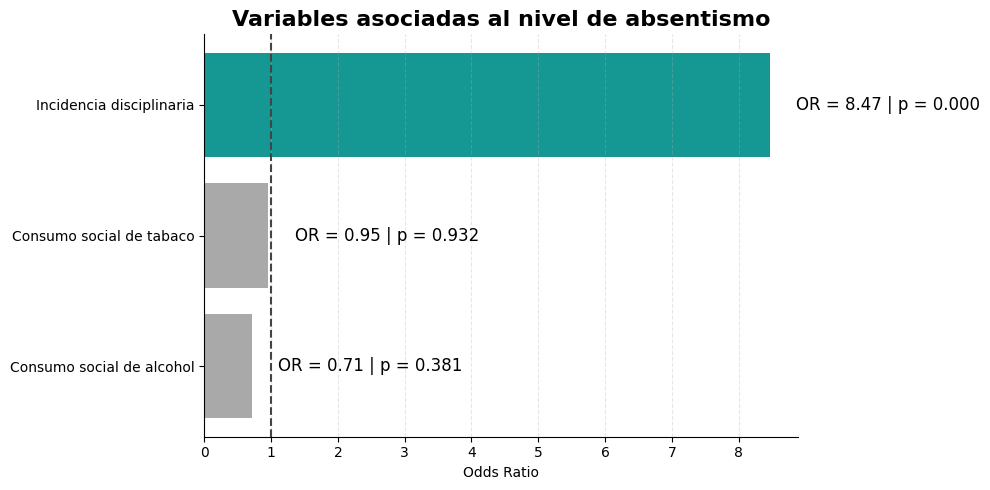

In [52]:
grafico = resultados_modelo_4.copy()

nombres = {
    "Social_Drinker": "Consumo social de alcohol",
    "Social_Smoker": "Consumo social de tabaco",
    "Disciplinary_Failure": "Incidencia disciplinaria"
}

grafico["Variable_Desc"] = grafico["Variable"].map(nombres)
grafico = grafico.sort_values("Odds_Ratio")

colores = [
    "#159793" if p < 0.05 else "#A9A9A9"
    for p in grafico["P_Value"]
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    grafico["Variable_Desc"],
    grafico["Odds_Ratio"],
    color=colores
)

# Línea OR = 1
ax.axvline(
    1,
    color="#444444",
    linestyle="--",
    linewidth=1.5
)

# Etiquetas
for bar, or_value, p_value in zip(
    bars,
    grafico["Odds_Ratio"],
    grafico["P_Value"]
):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"OR = {or_value:.2f} | p = {p_value:.3f}",
        va="center",
        fontsize=12
    )

ax.set_title(
    "Variables asociadas al nivel de absentismo",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Odds Ratio")

ax.grid(axis="x", linestyle="--", alpha=0.3)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()